## 07 - Comparação e Seleção dos Modelos

**Tech Challenge — Fase 1 | Machine Learning Engineering — FIAP**

**Projeto:** Customer Churn Prediction

**Grupo:** 56

---

### ETAPA 1 - Introdução e Objetivos

Após o desenvolvimento e a avaliação individual dos modelos, esta etapa tem como objetivo consolidar os resultados e selecionar a abordagem mais adequada para a previsão de churn.

Serão comparados:

1. DummyClassifier;
2. Regressão Logística;
3. Random Forest;
4. MLPClassifier do Scikit-Learn;
5. MLP desenvolvida com PyTorch.

O DummyClassifier será utilizado como referência ingênua, permitindo verificar se os modelos treinados apresentam ganho real em relação a uma estratégia sem capacidade preditiva efetiva.

Para garantir consistência, a comparação principal utilizará as métricas obtidas sobre o mesmo conjunto de teste, com divisão estratificada, seed 42 e threshold padrão de 0,50.

Serão avaliadas:

- Accuracy;
- Precision;
- Recall;
- F1-Score;
- ROC-AUC;
- Average Precision;
- estabilidade na validação cruzada;
- comportamento dos falsos positivos e falsos negativos;
- impacto potencial dos erros para o negócio;
- complexidade e adequação para inferência.

A seleção do modelo campeão não será baseada exclusivamente em uma única métrica. A decisão considerará conjuntamente desempenho preditivo, estabilidade, custo dos erros e requisitos técnicos do projeto.

### Objetivos

- construir a referência com DummyClassifier;
- consolidar as métricas dos modelos;
- comparar os resultados no conjunto de teste;
- comparar os resultados da validação cruzada;
- analisar os ganhos em relação à referência ingênua;
- avaliar o equilíbrio entre Precision e Recall;
- considerar o custo dos falsos positivos e falsos negativos;
- selecionar o modelo campeão;
- documentar os critérios utilizados na decisão;
- preparar o modelo selecionado para persistência, MLflow e API.

---

In [1]:
# ============================================================
# ETAPA 2 - IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

# ------------------------------------------------------------
# Configurações gerais
# ------------------------------------------------------------

RANDOM_STATE = 42
THRESHOLD_DEFAULT = 0.50

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_colwidth",
    None
)

# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

print(
    "Bibliotecas importadas com sucesso."
)

print(
    f"Random State: "
    f"{RANDOM_STATE}"
)

print(
    f"Threshold padrão da comparação: "
    f"{THRESHOLD_DEFAULT:.2f}"
)

Bibliotecas importadas com sucesso.
Random State: 42
Threshold padrão da comparação: 0.50


In [2]:
# ============================================================
# ETAPA 3 - CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ============================================================

DATASET_NAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

current_path = Path.cwd().resolve()

project_root = None

# ------------------------------------------------------------
# Busca pela raiz do projeto
# ------------------------------------------------------------

for path in [
    current_path,
    *current_path.parents
]:

    candidate = (
        path
        / "data"
        / "raw"
        / DATASET_NAME
    )

    if candidate.exists():

        project_root = path
        break


if project_root is None:

    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto contendo "
        f"data/raw/{DATASET_NAME}"
    )


DATA_PATH = (
    project_root
    / "data"
    / "raw"
    / DATASET_NAME
)


# ------------------------------------------------------------
# Carregamento
# ------------------------------------------------------------

df = pd.read_csv(
    DATA_PATH
)

df = df.copy()

# ------------------------------------------------------------
# Preparação
# ------------------------------------------------------------

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["Churn"] = (
    df["Churn"]
    .astype(str)
    .str.strip()
    .map({
        "No": 0,
        "Yes": 1
    })
)


# ------------------------------------------------------------
# Validação da variável alvo
# ------------------------------------------------------------

if df["Churn"].isna().any():

    raise ValueError(
        "Foram encontrados valores inválidos "
        "na variável alvo Churn."
    )


df["Churn"] = (
    df["Churn"]
    .astype(int)
)

# ------------------------------------------------------------
# Separação entre X e y
# ------------------------------------------------------------

X = df.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

y = df["Churn"]

# ------------------------------------------------------------
# Mesma divisão dos modelos anteriores
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Validações
# ------------------------------------------------------------

assert len(X_train) + len(X_test) == len(X)

assert set(X_train.index).isdisjoint(
    X_test.index
)

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print(
    "Dados preparados com sucesso."
)

print(
    f"Arquivo utilizado: "
    f"{DATA_PATH.name}"
)

print(
    f"Observações totais: "
    f"{len(X):,}"
    .replace(",", ".")
)

print(
    f"Variáveis explicativas: "
    f"{X.shape[1]}"
)

print(
    f"Treino: "
    f"{len(X_train):,}"
    .replace(",", ".")
)

print(
    f"Teste: "
    f"{len(X_test):,}"
    .replace(",", ".")
)

print(
    f"\nTaxa de Churn total: "
    f"{y.mean():.2%}"
)

print(
    f"Taxa de Churn no treino: "
    f"{y_train.mean():.2%}"
)

print(
    f"Taxa de Churn no teste: "
    f"{y_test.mean():.2%}"
)

Dados preparados com sucesso.
Arquivo utilizado: WA_Fn-UseC_-Telco-Customer-Churn.csv
Observações totais: 7.043
Variáveis explicativas: 19
Treino: 5.634
Teste: 1.409

Taxa de Churn total: 26.54%
Taxa de Churn no treino: 26.54%
Taxa de Churn no teste: 26.54%


---

### ETAPA 4 - Referência Ingênua com DummyClassifier

O DummyClassifier será utilizado como referência mínima de desempenho.

Será adotada a estratégia `prior`, que aprende somente a distribuição das classes no conjunto de treino, sem utilizar relações entre as variáveis explicativas e o target.

Como a classe sem churn é majoritária, a classe prevista pelo modelo deverá ser sempre 0.

As probabilidades serão determinadas pela proporção observada no conjunto de treino. Dessa forma, o DummyClassifier representa uma estratégia sem capacidade discriminativa, mas permite verificar se os modelos treinados oferecem ganho real.

In [4]:
# ============================================================
# ETAPA 4 - DUMMYCLASSIFIER
# ============================================================

# ------------------------------------------------------------
# Feature constante
# ------------------------------------------------------------

X_train_dummy = np.zeros(
    shape=(
        len(y_train),
        1
    ),
    dtype=np.float32
)

X_test_dummy = np.zeros(
    shape=(
        len(y_test),
        1
    ),
    dtype=np.float32
)

# ------------------------------------------------------------
# Construção e treinamento
# ------------------------------------------------------------

dummy_model = DummyClassifier(
    strategy="prior",
    random_state=RANDOM_STATE
)

dummy_training_start = perf_counter()

dummy_model.fit(
    X_train_dummy,
    y_train
)

dummy_training_time = (
    perf_counter()
    - dummy_training_start
)

# ------------------------------------------------------------
# Predições
# ------------------------------------------------------------

y_pred_dummy = dummy_model.predict(
    X_test_dummy
)

positive_class_index = np.where(
    dummy_model.classes_ == 1
)[0][0]

y_proba_dummy = dummy_model.predict_proba(
    X_test_dummy
)[:, positive_class_index]

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

accuracy_dummy = accuracy_score(
    y_test,
    y_pred_dummy
)

precision_dummy = precision_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

recall_dummy = recall_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

f1_dummy = f1_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

roc_auc_dummy = roc_auc_score(
    y_test,
    y_proba_dummy
)

average_precision_dummy = average_precision_score(
    y_test,
    y_proba_dummy
)


# ------------------------------------------------------------
# Matriz de confusão
# ------------------------------------------------------------

dummy_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_dummy
)

tn_dummy, fp_dummy, fn_dummy, tp_dummy = (
    dummy_confusion_matrix.ravel()
)

# ------------------------------------------------------------
# Tabela
# ------------------------------------------------------------

metrics_dummy = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Valor": [
        accuracy_dummy,
        precision_dummy,
        recall_dummy,
        f1_dummy,
        roc_auc_dummy,
        average_precision_dummy
    ]
})

# ------------------------------------------------------------
# Exibição
# ------------------------------------------------------------

print(
    "Desempenho do DummyClassifier no conjunto de teste:\n"
)

print(
    f"Accuracy:          "
    f"{accuracy_dummy:.4f}"
)

print(
    f"Precision:         "
    f"{precision_dummy:.4f}"
)

print(
    f"Recall:            "
    f"{recall_dummy:.4f}"
)

print(
    f"F1-Score:          "
    f"{f1_dummy:.4f}"
)

print(
    f"ROC-AUC:           "
    f"{roc_auc_dummy:.4f}"
)

print(
    f"Average Precision: "
    f"{average_precision_dummy:.4f}"
)

print(
    f"Tempo de treinamento: "
    f"{dummy_training_time:.6f} segundos"
)

print(
    "\nMatriz de Confusão:"
)

print(
    f"TN: {tn_dummy} | "
    f"FP: {fp_dummy} | "
    f"FN: {fn_dummy} | "
    f"TP: {tp_dummy}"
)


display(
    metrics_dummy.style.format({
        "Valor": "{:.4f}"
    })
)

Desempenho do DummyClassifier no conjunto de teste:

Accuracy:          0.7346
Precision:         0.0000
Recall:            0.0000
F1-Score:          0.0000
ROC-AUC:           0.5000
Average Precision: 0.2654
Tempo de treinamento: 0.002034 segundos

Matriz de Confusão:
TN: 1035 | FP: 0 | FN: 374 | TP: 0


,Métrica,Valor
0,Accuracy,0.7346
1,Precision,0.0000
2,Recall,0.0000
3,F1-Score,0.0000
4,ROC-AUC,0.5000
5,Average Precision,0.2654


#### Análise do DummyClassifier

O DummyClassifier apresentou Accuracy de **73,46%**, mas esse resultado não representa capacidade real de previsão.

Como a estratégia utilizada considera apenas a distribuição das classes, o modelo classificou todas as 1.409 observações como não churn.

Consequentemente, a matriz de confusão apresentou:

- 1.035 verdadeiros negativos;
- nenhum falso positivo;
- 374 falsos negativos;
- nenhum verdadeiro positivo.

A Precision, o Recall e o F1-Score da classe positiva foram iguais a zero, pois nenhum cliente foi classificado como churn.

A ROC-AUC de **0,5000** confirma que o modelo não possui capacidade discriminativa. A Average Precision de **0,2654** corresponde à própria prevalência de churn no conjunto de teste.

O resultado demonstra que a Accuracy de 73,46% é consequência do desbalanceamento das classes. Por isso, a comparação dos modelos deverá priorizar Average Precision, Recall, F1-Score e ROC-AUC.

O DummyClassifier estabelece, portanto, a referência mínima que os modelos treinados deverão superar.

---


### ETAPA 5 - Consolidação dos Resultados no Conjunto de Teste

Nesta etapa serão consolidadas as métricas obtidas pelos cinco modelos sobre o mesmo conjunto de teste, contendo 1.409 observações.

Todos os valores correspondem ao threshold padrão de 0,50 e foram obtidos nos respectivos notebooks de experimentação.

A tabela permitirá comparar diretamente:

- desempenho geral;
- capacidade de identificação da classe positiva;
- equilíbrio entre Precision e Recall;
- capacidade discriminativa;
- capacidade de priorização de clientes com churn.

A Average Precision será mantida como principal referência técnica, conforme estabelecido na definição das métricas do projeto.

In [5]:
# ============================================================
# ETAPA 5 - RESULTADOS HOLD-OUT DOS MODELOS
# ============================================================

holdout_results = pd.DataFrame({
    "Modelo": [
        "DummyClassifier",
        "Regressão Logística",
        "Random Forest",
        "MLPClassifier",
        "MLP PyTorch"
    ],
    "Accuracy": [
        accuracy_dummy,
        0.8055,
        0.7729,
        0.7850,
        0.7956
    ],
    "Precision": [
        precision_dummy,
        0.6572,
        0.5544,
        0.6330,
        0.6344
    ],
    "Recall": [
        recall_dummy,
        0.5588,
        0.7353,
        0.4519,
        0.5428
    ],
    "F1-Score": [
        f1_dummy,
        0.6040,
        0.6322,
        0.5273,
        0.5850
    ],
    "ROC-AUC": [
        roc_auc_dummy,
        0.8419,
        0.8401,
        0.8341,
        0.8419
    ],
    "Average Precision": [
        average_precision_dummy,
        0.6334,
        0.6492,
        0.6231,
        0.6349
    ]
})


# ------------------------------------------------------------
# Identificação do melhor resultado por métrica
# ------------------------------------------------------------

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Average Precision"
]

best_models_holdout = pd.DataFrame({
    "Métrica": metric_columns,
    "Melhor Modelo": [
        holdout_results.loc[
            holdout_results[metric].idxmax(),
            "Modelo"
        ]
        for metric in metric_columns
    ],
    "Melhor Valor": [
        holdout_results[metric].max()
        for metric in metric_columns
    ]
})

# ------------------------------------------------------------
# Exibição da tabela principal
# ------------------------------------------------------------

display(
    holdout_results.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}"
    })
    .highlight_max(
        subset=metric_columns,
        color="#90EE90"
    )
)

# ------------------------------------------------------------
# Exibição dos melhores resultados
# ------------------------------------------------------------

print(
    "Melhor Resultado por Métrica\n"
)

display(
    best_models_holdout.style.format({
        "Melhor Valor": "{:.4f}"
    })
)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
0,DummyClassifier,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654
1,Regressão Logística,0.8055,0.6572,0.5588,0.6040,0.8419,0.6334
2,Random Forest,0.7729,0.5544,0.7353,0.6322,0.8401,0.6492
3,MLPClassifier,0.7850,0.6330,0.4519,0.5273,0.8341,0.6231
4,MLP PyTorch,0.7956,0.6344,0.5428,0.5850,0.8419,0.6349


Melhor Resultado por Métrica



,Métrica,Melhor Modelo,Melhor Valor
0,Accuracy,Regressão Logística,0.8055
1,Precision,Regressão Logística,0.6572
2,Recall,Random Forest,0.7353
3,F1-Score,Random Forest,0.6322
4,ROC-AUC,Regressão Logística,0.8419
5,Average Precision,Random Forest,0.6492


#### Análise Comparativa dos Resultados Hold-out

A comparação demonstra que todos os modelos treinados superaram amplamente o DummyClassifier em capacidade discriminativa e identificação da classe positiva.

O DummyClassifier apresentou Accuracy de 73,46%, mas não identificou nenhum cliente com churn. Esse resultado reforça que a Accuracy isolada não é suficiente para avaliar o problema.

A **Regressão Logística** apresentou:

- maior Accuracy, com 80,55%;
- maior Precision, com 65,72%;
- ROC-AUC de 0,8419, empatada com a MLP PyTorch no nível de precisão registrado.

Esse comportamento indica uma abordagem mais conservadora, com menor proporção de alertas incorretos e bom desempenho geral.

O **Random Forest** apresentou:

- maior Recall, com 73,53%;
- maior F1-Score, com 0,6322;
- maior Average Precision, com 0,6492.

Como a Average Precision foi definida como principal referência técnica, o Random Forest apresentou o melhor resultado hold-out nesse critério. O modelo também identificou a maior parcela dos clientes com churn, mas apresentou menor Precision, refletindo uma quantidade maior de falsos positivos.

O **MLPClassifier do Scikit-Learn** apresentou os menores resultados entre os modelos efetivamente treinados em Recall, F1-Score, ROC-AUC e Average Precision.

A **MLP PyTorch** superou o MLPClassifier do Scikit-Learn em todas as métricas avaliadas. Também apresentou ROC-AUC de 0,8419, empatando com a Regressão Logística, além de desempenho equilibrado entre Accuracy, Precision, Recall e Average Precision.

Os resultados hold-out favorecem o Random Forest quando a prioridade é identificar clientes com churn e maximizar a Average Precision. Entretanto, a seleção definitiva ainda deverá considerar a estabilidade na validação cruzada, o custo dos erros e a adequação técnica do modelo para o projeto.

---

### ETAPA 6 - Visualização Comparativa das Métricas

Os resultados serão visualizados em dois grupos.

O primeiro gráfico apresentará as métricas dependentes do threshold padrão:

- Accuracy;
- Precision;
- Recall;
- F1-Score.

O segundo apresentará as métricas calculadas a partir das probabilidades em diferentes thresholds:

- ROC-AUC;
- Average Precision.

Essa separação evita misturar visualmente métricas que avaliam aspectos diferentes do comportamento dos modelos.

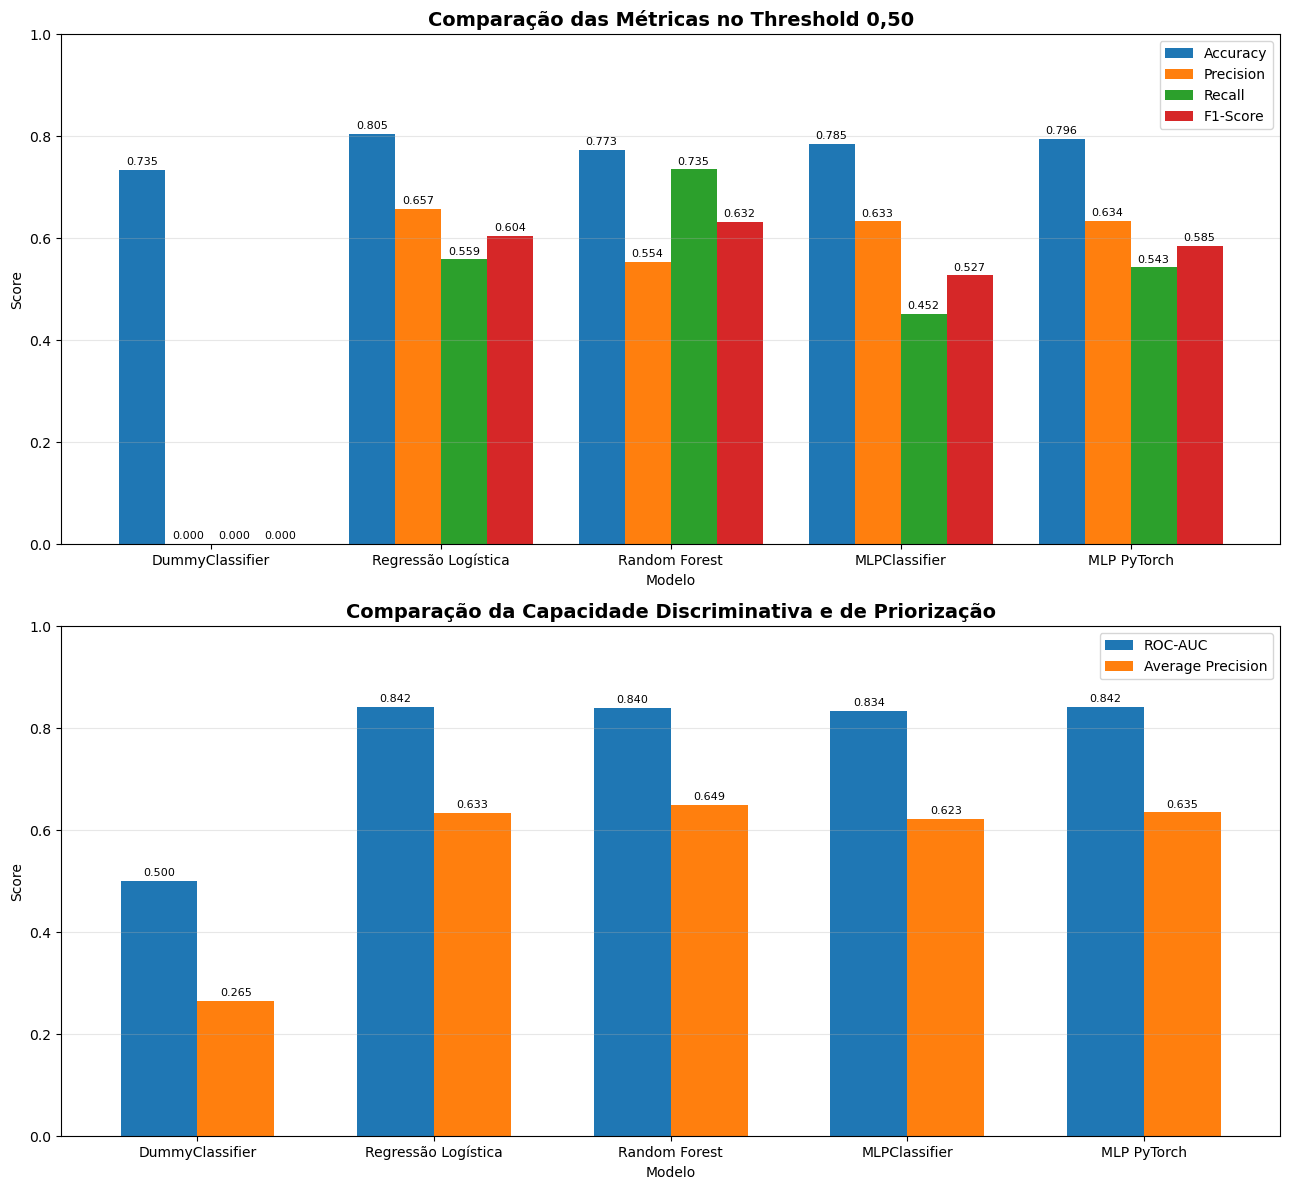

In [6]:
# ============================================================
# ETAPA 6 - GRÁFICOS COMPARATIVOS
# ============================================================

threshold_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

probability_metrics = [
    "ROC-AUC",
    "Average Precision"
]

# ------------------------------------------------------------
# Preparação
# ------------------------------------------------------------

comparison_plot_data = (
    holdout_results
    .set_index("Modelo")
)

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 12)
)


comparison_plot_data[
    threshold_metrics
].plot(
    kind="bar",
    ax=axes[0],
    width=0.80
)

axes[0].set_title(
    "Comparação das Métricas no Threshold 0,50",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Modelo"
)

axes[0].set_ylabel(
    "Score"
)

axes[0].set_ylim(
    0,
    1
)

axes[0].tick_params(
    axis="x",
    rotation=0
)

axes[0].legend(
    loc="upper right"
)

axes[0].grid(
    axis="y",
    alpha=0.3
)


comparison_plot_data[
    probability_metrics
].plot(
    kind="bar",
    ax=axes[1],
    width=0.65
)

axes[1].set_title(
    "Comparação da Capacidade Discriminativa e de Priorização",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Modelo"
)

axes[1].set_ylabel(
    "Score"
)

axes[1].set_ylim(
    0,
    1
)

axes[1].tick_params(
    axis="x",
    rotation=0
)

axes[1].legend(
    loc="upper right"
)

axes[1].grid(
    axis="y",
    alpha=0.3
)

# ------------------------------------------------------------
# Rótulos dos valores
# ------------------------------------------------------------

for axis in axes:

    for container in axis.containers:

        axis.bar_label(
            container,
            fmt="%.3f",
            fontsize=8,
            padding=2
        )


plt.tight_layout()

plt.show()

#### Análise Visual das Métricas

O primeiro gráfico evidencia as diferenças entre os modelos no threshold padrão de 0,50.

A Regressão Logística apresentou os maiores valores de Accuracy e Precision, demonstrando comportamento mais conservador e menor proporção de alertas incorretos.

O Random Forest apresentou o maior Recall e o maior F1-Score. Isso demonstra maior capacidade de identificar clientes que efetivamente realizaram churn, embora sua Precision tenha sido a menor entre os modelos treinados.

A MLP PyTorch apresentou desempenho mais equilibrado que o MLPClassifier do Scikit-Learn, superando-o em todas as métricas avaliadas.

O segundo gráfico mostra que Regressão Logística, Random Forest e MLP PyTorch apresentaram resultados muito próximos em ROC-AUC. Isso indica que os três modelos possuem capacidade discriminativa global semelhante.

A Average Precision apresentou maior diferenciação. O Random Forest alcançou o maior resultado, com 0,6492, seguido pela MLP PyTorch, com 0,6349, e pela Regressão Logística, com 0,6334.

Os gráficos também reforçam a limitação do DummyClassifier: apesar de sua Accuracy aparentemente elevada, suas métricas relacionadas à classe positiva foram iguais a zero e sua capacidade discriminativa permaneceu na referência aleatória.

---

### ETAPA 7 - Ganhos em Relação à Referência Ingênua

Os modelos treinados serão comparados com o DummyClassifier para quantificar o ganho absoluto obtido em cada métrica.

Como o DummyClassifier possui Precision, Recall e F1-Score iguais a zero, serão utilizados ganhos absolutos em pontos decimais, e não variações percentuais relativas.

Também será calculada a razão entre a Average Precision de cada modelo e a baseline do DummyClassifier.

In [7]:
# ============================================================
# ETAPA 7 - GANHOS EM RELAÇÃO AO DUMMYCLASSIFIER
# ============================================================

dummy_reference = (
    holdout_results[
        holdout_results["Modelo"]
        == "DummyClassifier"
    ]
    .iloc[0]
)


trained_models_results = (
    holdout_results[
        holdout_results["Modelo"]
        != "DummyClassifier"
    ]
    .copy()
)

# ------------------------------------------------------------
# Ganhos absolutos
# ------------------------------------------------------------

gains_vs_dummy = pd.DataFrame({
    "Modelo": (
        trained_models_results["Modelo"]
        .to_numpy()
    ),
    "Ganho Accuracy": (
        trained_models_results["Accuracy"]
        - dummy_reference["Accuracy"]
    ),
    "Ganho Precision": (
        trained_models_results["Precision"]
        - dummy_reference["Precision"]
    ),
    "Ganho Recall": (
        trained_models_results["Recall"]
        - dummy_reference["Recall"]
    ),
    "Ganho F1-Score": (
        trained_models_results["F1-Score"]
        - dummy_reference["F1-Score"]
    ),
    "Ganho ROC-AUC": (
        trained_models_results["ROC-AUC"]
        - dummy_reference["ROC-AUC"]
    ),
    "Ganho Average Precision": (
        trained_models_results["Average Precision"]
        - dummy_reference["Average Precision"]
    ),
    "AP / Baseline": (
        trained_models_results["Average Precision"]
        / dummy_reference["Average Precision"]
    )
})

# ------------------------------------------------------------
# Exibição
# ------------------------------------------------------------

display(
    gains_vs_dummy.style
    .format({
        "Ganho Accuracy": "{:+.4f}",
        "Ganho Precision": "{:+.4f}",
        "Ganho Recall": "{:+.4f}",
        "Ganho F1-Score": "{:+.4f}",
        "Ganho ROC-AUC": "{:+.4f}",
        "Ganho Average Precision": "{:+.4f}",
        "AP / Baseline": "{:.2f}x"
    })
    .highlight_max(
        subset=[
            "Ganho Accuracy",
            "Ganho Precision",
            "Ganho Recall",
            "Ganho F1-Score",
            "Ganho ROC-AUC",
            "Ganho Average Precision",
            "AP / Baseline"
        ],
        color="#90EE90"
    )
)

,Modelo,Ganho Accuracy,Ganho Precision,Ganho Recall,Ganho F1-Score,Ganho ROC-AUC,Ganho Average Precision,AP / Baseline
1,Regressão Logística,+0.0709,+0.6572,+0.5588,+0.6040,+0.3419,+0.3680,2.39x
2,Random Forest,+0.0383,+0.5544,+0.7353,+0.6322,+0.3401,+0.3838,2.45x
3,MLPClassifier,+0.0504,+0.6330,+0.4519,+0.5273,+0.3341,+0.3577,2.35x
4,MLP PyTorch,+0.0610,+0.6344,+0.5428,+0.5850,+0.3419,+0.3695,2.39x


#### Análise dos Ganhos em Relação ao DummyClassifier

Todos os modelos treinados apresentaram ganhos substanciais em relação à referência ingênua.

A Regressão Logística apresentou o maior ganho de Accuracy, com 0,0709, e de Precision, com 0,6572.

O Random Forest apresentou os maiores ganhos em:

- Recall: 0,7353;
- F1-Score: 0,6322;
- Average Precision: 0,3838.

Sua Average Precision foi aproximadamente **2,45 vezes maior** que a baseline de 0,2654.

A MLP PyTorch e a Regressão Logística apresentaram o maior ganho de ROC-AUC, com 0,3419 em relação à referência aleatória.

A MLP PyTorch alcançou Average Precision aproximadamente 2,39 vezes superior à baseline, enquanto o MLPClassifier atingiu aproximadamente 2,35 vezes.

Esses resultados confirmam que os modelos aprenderam relações relevantes entre as características dos clientes e a ocorrência de churn, superando uma estratégia baseada somente na distribuição das classes.

---

### ETAPA 8 - Comparação dos Erros e do Custo Relativo

As matrizes de confusão serão consolidadas para comparar diretamente a quantidade de verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos produzidos por cada modelo.

Também será aplicada a mesma simulação de custo utilizada na análise da MLP PyTorch:

- custo de um falso positivo: 1;
- custo de um falso negativo: 5.

Essa premissa representa um cenário hipotético em que deixar de identificar um cliente com churn possui impacto cinco vezes superior ao custo de uma abordagem de retenção desnecessária.

Todos os valores correspondem ao threshold padrão de 0,50.

In [8]:
# ============================================================
# ETAPA 8.1 - MATRIZES DE CONFUSÃO E CUSTO RELATIVO
# ============================================================

COST_FP = 1
COST_FN = 5

# ------------------------------------------------------------
# Consolidação das matrizes
# ------------------------------------------------------------

confusion_results = pd.DataFrame({
    "Modelo": [
        "DummyClassifier",
        "Regressão Logística",
        "Random Forest",
        "MLPClassifier",
        "MLP PyTorch"
    ],
    "TN": [
        1035,
        926,
        814,
        937,
        918
    ],
    "FP": [
        0,
        109,
        221,
        98,
        117
    ],
    "FN": [
        374,
        165,
        99,
        205,
        171
    ],
    "TP": [
        0,
        209,
        275,
        169,
        203
    ]
})

# ------------------------------------------------------------
# Indicadores derivados
# ------------------------------------------------------------

confusion_results["Acertos"] = (
    confusion_results["TN"]
    + confusion_results["TP"]
)

confusion_results["Erros"] = (
    confusion_results["FP"]
    + confusion_results["FN"]
)

confusion_results["Predições Positivas"] = (
    confusion_results["FP"]
    + confusion_results["TP"]
)

confusion_results["Custo FP"] = (
    confusion_results["FP"]
    * COST_FP
)

confusion_results["Custo FN"] = (
    confusion_results["FN"]
    * COST_FN
)

confusion_results["Custo Relativo Total"] = (
    confusion_results["Custo FP"]
    + confusion_results["Custo FN"]
)

# ------------------------------------------------------------
# Validação dos totais
# ------------------------------------------------------------

for _, row in confusion_results.iterrows():

    total_observations = (
        row["TN"]
        + row["FP"]
        + row["FN"]
        + row["TP"]
    )

    if total_observations != len(y_test):

        raise ValueError(
            f"A matriz do modelo {row['Modelo']} "
            "não totaliza o conjunto de teste."
        )

# ------------------------------------------------------------
# Exibição
# ------------------------------------------------------------

display(
    confusion_results.style
    .format({
        "TN": "{:.0f}",
        "FP": "{:.0f}",
        "FN": "{:.0f}",
        "TP": "{:.0f}",
        "Acertos": "{:.0f}",
        "Erros": "{:.0f}",
        "Predições Positivas": "{:.0f}",
        "Custo FP": "{:.0f}",
        "Custo FN": "{:.0f}",
        "Custo Relativo Total": "{:.0f}"
    })
    .highlight_min(
        subset=[
            "FN",
            "Custo Relativo Total"
        ],
        color="#90EE90"
    )
    .highlight_max(
        subset=[
            "TP"
        ],
        color="#90EE90"
    )
)

,Modelo,TN,FP,FN,TP,Acertos,Erros,Predições Positivas,Custo FP,Custo FN,Custo Relativo Total
0,DummyClassifier,1035,0,374,0,1035,374,0,0,1870,1870
1,Regressão Logística,926,109,165,209,1135,274,318,109,825,934
2,Random Forest,814,221,99,275,1089,320,496,221,495,716
3,MLPClassifier,937,98,205,169,1106,303,267,98,1025,1123
4,MLP PyTorch,918,117,171,203,1121,288,320,117,855,972


#### Análise Comparativa dos Erros e do Custo Relativo

A comparação das matrizes de confusão demonstra que a quantidade total de acertos não é suficiente para selecionar o modelo mais adequado ao negócio.

A Regressão Logística apresentou o maior número de classificações corretas, com **1.135 acertos**, e o menor número total de erros entre os modelos treinados, com 274.

Entretanto, 165 de seus erros foram falsos negativos, representando clientes com churn que não seriam identificados para ações preventivas.

O Random Forest apresentou:

- 275 verdadeiros positivos;
- 99 falsos negativos;
- 221 falsos positivos;
- custo relativo total de 716 unidades.

Embora tenha produzido 320 erros totais, o Random Forest apresentou o menor custo relativo porque identificou uma parcela maior dos clientes com churn.

A MLP PyTorch apresentou 203 verdadeiros positivos e 171 falsos negativos, resultando em custo relativo de 972 unidades.

O MLPClassifier apresentou o maior custo entre os modelos efetivamente treinados, com 1.123 unidades, principalmente devido aos 205 falsos negativos.

O DummyClassifier apresentou 1.035 acertos, mas todos corresponderam à classe negativa. Como deixou de identificar os 374 clientes com churn, seu custo relativo atingiu 1.870 unidades.

Na simulação adotada, o Random Forest reduziu o custo em aproximadamente:

- 61,71% em relação ao DummyClassifier;
- 23,34% em relação à Regressão Logística;
- 26,34% em relação à MLP PyTorch.

Os resultados reforçam que, quando falsos negativos possuem maior impacto, o modelo com maior Accuracy não necessariamente representa a melhor escolha para o negócio.

---

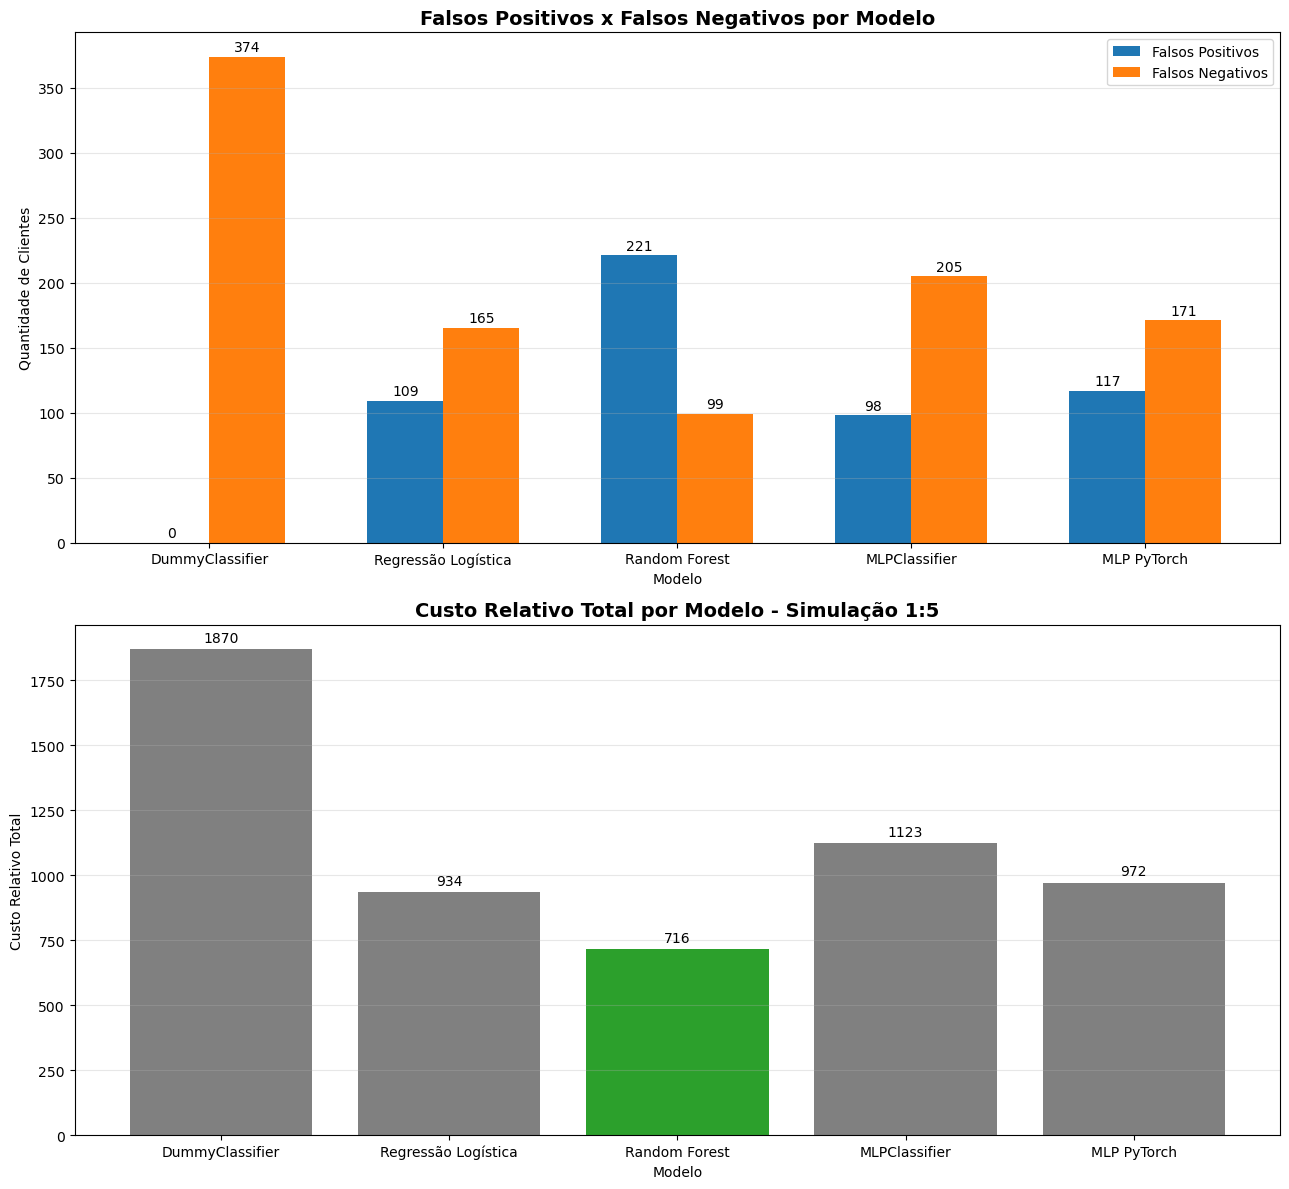

In [12]:
# ============================================================
# ETAPA 8.2 - VISUALIZAÇÃO DOS ERROS E CUSTOS
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 12)
)

# ------------------------------------------------------------
# Falsos Positivos x Falsos Negativos
# ------------------------------------------------------------

confusion_results[
    [
        "Modelo",
        "FP",
        "FN"
    ]
].set_index(
    "Modelo"
).plot(
    kind="bar",
    ax=axes[0],
    width=0.65
)

axes[0].set_title(
    "Falsos Positivos x Falsos Negativos por Modelo",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Modelo"
)

axes[0].set_ylabel(
    "Quantidade de Clientes"
)

axes[0].tick_params(
    axis="x",
    rotation=0
)

axes[0].legend(
    [
        "Falsos Positivos",
        "Falsos Negativos"
    ]
)

axes[0].grid(
    axis="y",
    alpha=0.3
)


for container in axes[0].containers:

    axes[0].bar_label(
        container,
        fmt="%.0f",
        padding=2
    )

# ------------------------------------------------------------
# Custo relativo
# ------------------------------------------------------------

cost_colors = [
    "#808080"
    if model != "Random Forest"
    else "#2ca02c"
    for model in confusion_results["Modelo"]
]

cost_bars = axes[1].bar(
    confusion_results["Modelo"],
    confusion_results["Custo Relativo Total"],
    color=cost_colors
)

axes[1].set_title(
    "Custo Relativo Total por Modelo - Simulação 1:5",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Modelo"
)

axes[1].set_ylabel(
    "Custo Relativo Total"
)

axes[1].tick_params(
    axis="x",
    rotation=0
)

axes[1].grid(
    axis="y",
    alpha=0.3
)

axes[1].bar_label(
    cost_bars,
    fmt="%.0f",
    padding=3
)

plt.tight_layout()
plt.show()

#### Análise Visual dos Erros e Custos

O gráfico de Falsos Positivos e Falsos Negativos evidencia que os modelos apresentam comportamentos distintos na identificação dos clientes com risco de churn.

O DummyClassifier não identificou nenhum cliente da classe positiva, resultando em 374 Falsos Negativos. Esse comportamento confirma que sua Accuracy de 73,46% é consequência do desbalanceamento das classes e não representa capacidade real de prever churn.

A Regressão Logística apresentou um comportamento mais conservador, com 109 Falsos Positivos e 165 Falsos Negativos. Embora tenha obtido a maior Accuracy e Precision entre os modelos avaliados, deixou de identificar uma parcela relevante dos clientes que efetivamente realizaram churn.

O Random Forest apresentou 221 Falsos Positivos e apenas 99 Falsos Negativos. Portanto, o modelo gerou mais alertas incorretos, mas foi o que deixou passar a menor quantidade de clientes que efetivamente abandonaram a empresa. Esse resultado está diretamente relacionado ao seu maior Recall, de 73,53%.

O MLPClassifier apresentou o menor número de Falsos Positivos entre os modelos treinados, com 98 ocorrências. Entretanto, também apresentou 205 Falsos Negativos, indicando menor capacidade de identificar clientes que efetivamente realizaram churn.

A MLP desenvolvida com PyTorch apresentou um comportamento intermediário, registrando 117 Falsos Positivos e 171 Falsos Negativos. Seu resultado ficou próximo ao da Regressão Logística, embora com uma quantidade ligeiramente maior de ambos os tipos de erro.

Na simulação em que um Falso Negativo possui custo cinco vezes maior que um Falso Positivo, o Random Forest apresentou o menor custo relativo total, com 716 unidades. Esse valor foi inferior aos custos da Regressão Logística (934), da MLP PyTorch (972), do MLPClassifier (1.123) e do DummyClassifier (1.870).

O resultado demonstra que a escolha do melhor modelo depende não apenas da quantidade total de erros, mas também do impacto atribuído a cada tipo de erro. Nesse cenário, a maior capacidade do Random Forest de reduzir Falsos Negativos compensou o aumento de Falsos Positivos.

---

## ETAPA 9 — Comparação da Validação Cruzada Estratificada

A avaliação realizada em um único conjunto de teste permite comparar os modelos sobre as mesmas observações, mas o resultado pode sofrer influência da divisão específica utilizada.

Para analisar a estabilidade e a capacidade de generalização dos classificadores, esta etapa compara os resultados obtidos por meio de validação cruzada estratificada com cinco folds.

A estratificação preserva aproximadamente a proporção de clientes com e sem churn em cada divisão. Para cada métrica, serão analisadas:

- a média obtida nos cinco folds;
- o desvio-padrão entre os resultados;
- a diferença entre a média da validação cruzada e o resultado do conjunto de teste.

Um modelo com média elevada e baixo desvio-padrão apresenta desempenho mais consistente em diferentes subconjuntos dos dados.

In [15]:
# ============================================================
# ETAPA 9.1 - RESULTADOS DA VALIDAÇÃO CRUZADA
# ============================================================
# Consolidação dos resultados obtidos anteriormente nos
# notebooks individuais de cada modelo.
# ============================================================

# Resultados do Random Forest por fold
cv_random_forest = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": [
        0.7791,
        0.7595,
        0.7684,
        0.7817,
        0.7851,
    ],
    "Precision": [
        0.5635,
        0.5378,
        0.5475,
        0.5668,
        0.5764,
    ],
    "Recall": [
        0.7425,
        0.6656,
        0.7324,
        0.7525,
        0.7191,
    ],
    "F1-Score": [
        0.6407,
        0.5949,
        0.6266,
        0.6466,
        0.6399,
    ],
    "ROC-AUC": [
        0.8397,
        0.8329,
        0.8440,
        0.8495,
        0.8585,
    ],
    "Average Precision": [
        0.6257,
        0.6409,
        0.6818,
        0.6607,
        0.6659,
    ],
})

# Resultados do MLPClassifier por fold
cv_mlp_classifier = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": [
        0.8055,
        0.7892,
        0.8062,
        0.7841,
        0.7919,
    ],
    "Precision": [
        0.6799,
        0.5970,
        0.6391,
        0.6049,
        0.6262,
    ],
    "Recall": [
        0.5053,
        0.6337,
        0.6203,
        0.5335,
        0.5374,
    ],
    "F1-Score": [
        0.5798,
        0.6148,
        0.6296,
        0.5670,
        0.5784,
    ],
    "ROC-AUC": [
        0.8495,
        0.8395,
        0.8594,
        0.8259,
        0.8311,
    ],
    "Average Precision": [
        0.6427,
        0.6600,
        0.6837,
        0.6240,
        0.6314,
    ],
})

print(
    "Resultados da validação cruzada carregados "
    "com sucesso."
)

print(
    f"\nQuantidade de folds do Random Forest: "
    f"{len(cv_random_forest)}"
)

print(
    f"Quantidade de folds do MLPClassifier: "
    f"{len(cv_mlp_classifier)}"
)

print("\nResultados do Random Forest:")
display(cv_random_forest)

print("\nResultados do MLPClassifier:")
display(cv_mlp_classifier)

Resultados da validação cruzada carregados com sucesso.

Quantidade de folds do Random Forest: 5
Quantidade de folds do MLPClassifier: 5

Resultados do Random Forest:


,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
0,1,0.7791,0.5635,0.7425,0.6407,0.8397,0.6257
1,2,0.7595,0.5378,0.6656,0.5949,0.8329,0.6409
2,3,0.7684,0.5475,0.7324,0.6266,0.8440,0.6818
3,4,0.7817,0.5668,0.7525,0.6466,0.8495,0.6607
4,5,0.7851,0.5764,0.7191,0.6399,0.8585,0.6659



Resultados do MLPClassifier:


,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
0,1,0.8055,0.6799,0.5053,0.5798,0.8495,0.6427
1,2,0.7892,0.5970,0.6337,0.6148,0.8395,0.6600
2,3,0.8062,0.6391,0.6203,0.6296,0.8594,0.6837
3,4,0.7841,0.6049,0.5335,0.5670,0.8259,0.6240
4,5,0.7919,0.6262,0.5374,0.5784,0.8311,0.6314


#### Análise dos Resultados por Fold

Os resultados dos cinco folds permitem observar como o desempenho dos modelos varia quando diferentes partes da base são utilizadas para treinamento e validação.

O Random Forest manteve valores elevados de Recall em todos os folds, demonstrando consistência na identificação dos clientes que efetivamente realizaram churn. A menor pontuação de Recall foi observada no segundo fold, enquanto o melhor resultado ocorreu no quarto fold.

O MLPClassifier apresentou menor Recall e maior variação nessa métrica. Esse comportamento indica maior sensibilidade às observações utilizadas em cada divisão dos dados.

Nas métricas ROC-AUC e Average Precision, os dois modelos apresentaram resultados superiores às respectivas referências aleatórias. Entretanto, as médias e os desvios-padrão ainda devem ser calculados para permitir uma comparação objetiva da estabilidade.

---

### ETAPA 9.2 — Média e Desvio-Padrão das Métricas

Nesta etapa, os resultados dos cinco folds são resumidos por meio da média e do desvio-padrão.

A média representa o desempenho geral obtido durante a validação cruzada, enquanto o desvio-padrão indica quanto o resultado variou entre os folds.

Quanto menor o desvio-padrão, maior é a estabilidade do modelo em diferentes subconjuntos dos dados.

Os resultados da MLP PyTorch foram obtidos no notebook `06_mlp_pytorch.ipynb`, utilizando validação cruzada estratificada com cinco folds e o mesmo `Random State` adotado no projeto.

In [16]:
# ============================================================
# ETAPA 9.2 - MÉDIA E DESVIO-PADRÃO DA VALIDAÇÃO CRUZADA
# ============================================================
# Cálculo dos resultados médios e da variação entre os folds.
# ============================================================

metricas_cv = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Average Precision",
]

def resumir_validacao_cruzada(
    nome_modelo,
    resultados_folds,
):
    """
    Calcula a média e o desvio-padrão amostral das métricas
    obtidas nos folds da validação cruzada.
    """

    resumo = {
        "Modelo": nome_modelo,
    }

    for metrica in metricas_cv:
        resumo[f"{metrica} Média"] = (
            resultados_folds[metrica].mean()
        )

        resumo[f"{metrica} Desvio"] = (
            resultados_folds[metrica].std(ddof=1)
        )

    return resumo


# Resumo do Random Forest
resumo_cv_rf = resumir_validacao_cruzada(
    "Random Forest",
    cv_random_forest,
)

# Resumo do MLPClassifier
resumo_cv_mlp_classifier = resumir_validacao_cruzada(
    "MLPClassifier",
    cv_mlp_classifier,
)

# Resumo da MLP PyTorch obtido no notebook 06
resumo_cv_mlp_pytorch = {
    "Modelo": "MLP PyTorch",

    "Accuracy Média": 0.8012,
    "Accuracy Desvio": 0.0112,

    "Precision Média": 0.6537,
    "Precision Desvio": 0.0271,

    "Recall Média": 0.5340,
    "Recall Desvio": 0.0200,

    "F1-Score Média": 0.5878,
    "F1-Score Desvio": 0.0226,

    "ROC-AUC Média": 0.8419,
    "ROC-AUC Desvio": 0.0150,

    "Average Precision Média": 0.6488,
    "Average Precision Desvio": 0.0288,
}

# Tabela numérica completa
cv_summary = pd.DataFrame([
    resumo_cv_rf,
    resumo_cv_mlp_classifier,
    resumo_cv_mlp_pytorch,
])

# Arredondamento somente para apresentação
cv_summary_display = cv_summary.copy()

colunas_numericas_cv = (
    cv_summary_display
    .select_dtypes(include=np.number)
    .columns
)

cv_summary_display[colunas_numericas_cv] = (
    cv_summary_display[colunas_numericas_cv]
    .round(4)
)


print(
    "Resumo da validação cruzada calculado com sucesso."
)

print(
    f"\nModelos comparados: "
    f"{len(cv_summary)}"
)

print(
    f"Quantidade de métricas: "
    f"{len(metricas_cv)}"
)

display(
    cv_summary_display.style
    .set_properties(
        subset=["Modelo"],
        **{
            "text-align": "left",
            "font-weight": "bold",
        }
    )
    .set_properties(
        subset=colunas_numericas_cv.tolist(),
        **{
            "text-align": "center",
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
            ],
        }
    ])
)

Resumo da validação cruzada calculado com sucesso.

Modelos comparados: 3
Quantidade de métricas: 6


,Modelo,Accuracy Média,Accuracy Desvio,Precision Média,Precision Desvio,Recall Média,Recall Desvio,F1-Score Média,F1-Score Desvio,ROC-AUC Média,ROC-AUC Desvio,Average Precision Média,Average Precision Desvio
0,Random Forest,0.774800,0.010600,0.558400,0.015500,0.722400,0.034100,0.629700,0.020800,0.844900,0.009700,0.655000,0.021900
1,MLPClassifier,0.795400,0.010000,0.629400,0.032800,0.566000,0.057200,0.593900,0.026800,0.841100,0.013600,0.648400,0.024000
2,MLP PyTorch,0.801200,0.011200,0.653700,0.027100,0.534000,0.020000,0.587800,0.022600,0.841900,0.015000,0.648800,0.028800


#### Análise da Média e do Desvio-Padrão

A validação cruzada estratificada demonstrou que os modelos apresentam comportamentos distintos em relação à precisão das previsões, à identificação dos clientes com churn e à estabilidade entre os folds.

A MLP PyTorch apresentou a maior Accuracy média, com 80,12%, e a maior Precision média, com 65,37%. Esses resultados indicam que a rede neural produziu classificações gerais mais corretas e que, entre os clientes classificados como churn, apresentou a maior proporção de acertos.

O Random Forest apresentou o maior Recall médio, com 72,24%, superando o MLPClassifier, com 56,60%, e a MLP PyTorch, com 53,40%. Portanto, o Random Forest foi o modelo mais eficiente na identificação dos clientes que efetivamente realizaram churn.

Como consequência do Recall mais elevado, o Random Forest também alcançou o maior F1-Score médio, com 62,97%. Esse resultado demonstra um equilíbrio mais favorável entre Precision e Recall quando comparado aos demais modelos.

Na avaliação independente do threshold, o Random Forest apresentou a maior ROC-AUC média, com 84,49%, além do menor desvio-padrão nessa métrica, de 0,97 ponto percentual. Isso indica que o modelo manteve boa capacidade discriminativa e elevada estabilidade entre os folds.

O Random Forest também obteve a maior Average Precision média, com 65,50%, superando ligeiramente a MLP PyTorch, com 64,88%, e o MLPClassifier, com 64,84%. Como a Average Precision foi definida como principal referência técnica para a comparação dos modelos, esse resultado favorece o Random Forest.

Em relação à estabilidade, o MLP PyTorch apresentou o menor desvio-padrão de Recall, com 2,00 pontos percentuais. Apesar de seu Recall médio ser inferior ao do Random Forest, a rede neural apresentou menor variação na identificação da classe positiva entre as divisões.

O MLPClassifier apresentou resultados competitivos de Accuracy, Precision, ROC-AUC e Average Precision, mas não alcançou o melhor resultado médio em nenhuma das métricas avaliadas. Além disso, apresentou a maior variação de Recall, com desvio-padrão de 5,72 pontos percentuais.

#### Conclusão da ETAPA 9.2

Os resultados da validação cruzada confirmam que não existe um único modelo superior em todas as métricas.

A MLP PyTorch apresentou o melhor desempenho médio em Accuracy e Precision, sendo adequada para cenários nos quais se deseja maior confiabilidade nas classificações positivas e menor quantidade de alertas incorretos.

Entretanto, o Random Forest apresentou os melhores resultados médios de Recall, F1-Score, ROC-AUC e Average Precision. O modelo também manteve baixa variação de desempenho entre os folds, especialmente na ROC-AUC, demonstrando estabilidade e boa capacidade de generalização.

Considerando que o problema de churn possui classes desbalanceadas, que os Falsos Negativos possuem maior impacto para o negócio e que a Average Precision foi estabelecida como principal referência técnica, o Random Forest permanece como o modelo mais adequado entre os três avaliados.

Essa conclusão também é coerente com a análise realizada no conjunto de teste, na qual o Random Forest apresentou o maior Recall, o maior F1-Score, a maior Average Precision e o menor custo relativo na simulação de negócio.

---

### ETAPA 9.3 — Comparação Formatada da Validação Cruzada

Para facilitar a interpretação dos resultados, as médias e os desvios-padrão serão reunidos em uma única tabela.

Cada resultado será apresentado no formato `média ± desvio-padrão`, permitindo observar simultaneamente:

- o desempenho médio do modelo;
- a variação observada entre os cinco folds;
- a estabilidade de cada métrica.

Quanto maior a média, melhor o desempenho. Quanto menor o desvio-padrão, maior a estabilidade do modelo.

In [17]:
# ============================================================
# ETAPA 9.3 - TABELA FORMATADA DA VALIDAÇÃO CRUZADA
# ============================================================
# Apresentação dos resultados no formato:
# média ± desvio-padrão.
# ============================================================

cv_comparison_formatted = pd.DataFrame({
    "Modelo": cv_summary["Modelo"],
})


for metrica in metricas_cv:
    coluna_media = f"{metrica} Média"
    coluna_desvio = f"{metrica} Desvio"

    cv_comparison_formatted[metrica] = [
        (
            f"{media:.4f} ± "
            f"{desvio:.4f}"
        )
        for media, desvio in zip(
            cv_summary[coluna_media],
            cv_summary[coluna_desvio],
        )
    ]


print(
    "Comparação formatada da validação cruzada:"
)

display(
    cv_comparison_formatted.style
    .set_properties(
        subset=["Modelo"],
        **{
            "text-align": "left",
            "font-weight": "bold",
        }
    )
    .set_properties(
        subset=metricas_cv,
        **{
            "text-align": "center",
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
            ],
        }
    ])
)

Comparação formatada da validação cruzada:


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
0,Random Forest,0.7748 ± 0.0106,0.5584 ± 0.0155,0.7224 ± 0.0341,0.6297 ± 0.0208,0.8449 ± 0.0097,0.6550 ± 0.0219
1,MLPClassifier,0.7954 ± 0.0100,0.6294 ± 0.0328,0.5660 ± 0.0572,0.5939 ± 0.0268,0.8411 ± 0.0136,0.6484 ± 0.0240
2,MLP PyTorch,0.8012 ± 0.0112,0.6537 ± 0.0271,0.5340 ± 0.0200,0.5878 ± 0.0226,0.8419 ± 0.0150,0.6488 ± 0.0288


#### Análise da Comparação Formatada

A tabela consolidada permite comparar simultaneamente o desempenho médio e a estabilidade dos modelos durante a validação cruzada.

A MLP PyTorch apresentou a maior Accuracy média, com `0,8012 ± 0,0112`, e a maior Precision média, com `0,6537 ± 0,0271`. Isso indica que a rede neural produziu classificações gerais mais corretas e maior confiabilidade entre as previsões positivas.

O Random Forest alcançou o maior Recall médio, com `0,7224 ± 0,0341`, e o maior F1-Score médio, com `0,6297 ± 0,0208`. Portanto, foi o modelo que apresentou o melhor equilíbrio para identificar clientes com churn sem considerar apenas a quantidade total de acertos.

Nas métricas independentes do threshold padrão, o Random Forest também obteve os melhores resultados, com ROC-AUC de `0,8449 ± 0,0097` e Average Precision de `0,6550 ± 0,0219`.

O baixo desvio-padrão da ROC-AUC do Random Forest demonstra que sua capacidade de distinguir clientes com e sem churn permaneceu estável entre os folds.

O MLPClassifier apresentou resultados intermediários, sem superar simultaneamente a capacidade de identificação do Random Forest ou a Accuracy e a Precision da MLP PyTorch.

Considerando o desbalanceamento da base, a importância atribuída à classe positiva e a Average Precision definida como principal referência técnica, a validação cruzada favorece o Random Forest.

---

### ETAPA 9.4 — Comparação Visual da Validação Cruzada

Nesta etapa, as médias obtidas na validação cruzada serão apresentadas graficamente.

As barras representam o desempenho médio dos modelos, enquanto as linhas verticais representam o desvio-padrão observado entre os cinco folds.

Essa visualização permite comparar simultaneamente:

- o desempenho médio de cada modelo;
- a variação dos resultados;
- o equilíbrio entre Precision e Recall;
- a capacidade discriminativa;
- a capacidade de priorização dos clientes com churn.

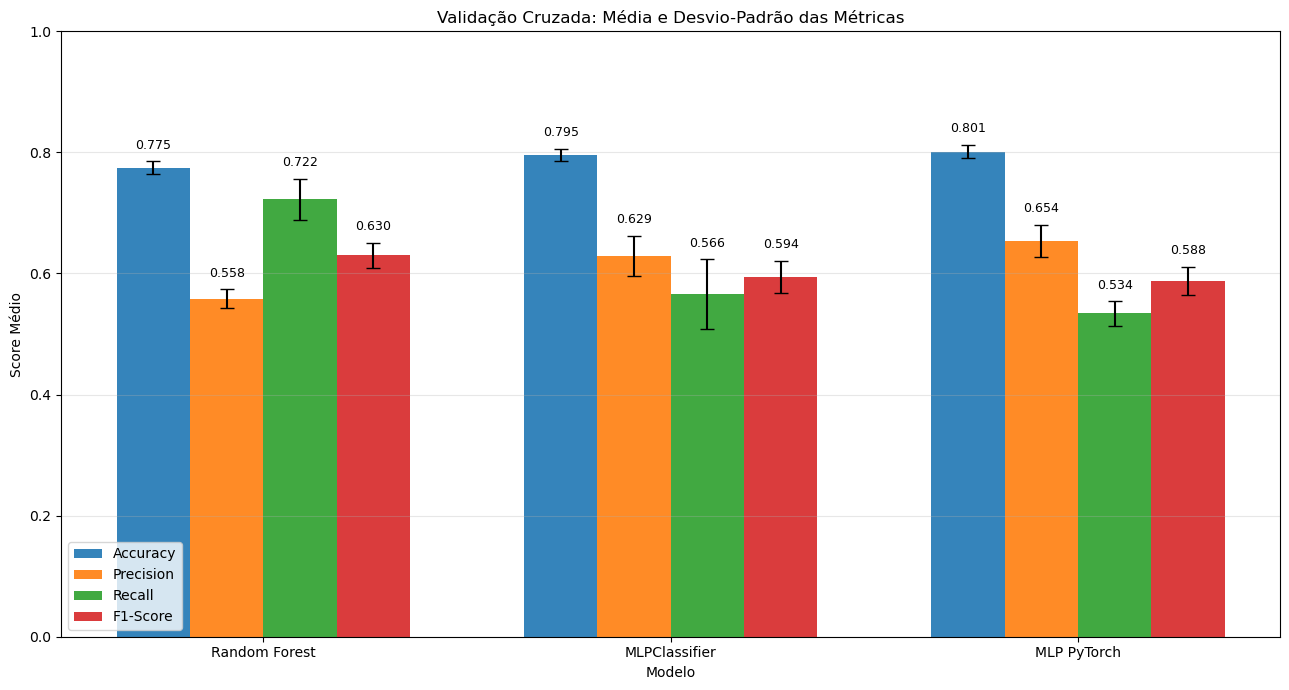

In [18]:
# ============================================================
# ETAPA 9.4.1 - MÉTRICAS DEPENDENTES DO THRESHOLD
# ============================================================
# Comparação das médias e dos desvios-padrão das métricas
# calculadas com o threshold padrão de 0.50.
# ============================================================

metricas_threshold_cv = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
]

modelos_cv = cv_summary["Modelo"].tolist()

x = np.arange(
    len(modelos_cv)
)

largura = 0.18

cores = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
]


fig, ax = plt.subplots(
    figsize=(13, 7)
)


for indice, (metrica, cor) in enumerate(
    zip(
        metricas_threshold_cv,
        cores,
    )
):
    medias = cv_summary[
        f"{metrica} Média"
    ].to_numpy()

    desvios = cv_summary[
        f"{metrica} Desvio"
    ].to_numpy()

    posicoes = (
        x
        + (
            indice
            - (
                len(metricas_threshold_cv) - 1
            ) / 2
        )
        * largura
    )

    barras = ax.bar(
        posicoes,
        medias,
        largura,
        yerr=desvios,
        capsize=5,
        label=metrica,
        color=cor,
        alpha=0.90,
    )

    ax.bar_label(
        barras,
        labels=[
            f"{valor:.3f}"
            for valor in medias
        ],
        padding=7,
        fontsize=9,
    )


ax.set_title(
    "Validação Cruzada: Média e Desvio-Padrão das Métricas"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "Score Médio"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    modelos_cv
)

ax.set_ylim(
    0,
    1
)

ax.legend(
    loc="lower left"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

plt.show()

#### Análise Visual das Métricas Dependentes do Threshold

O gráfico evidencia os diferentes comportamentos apresentados pelos modelos durante a validação cruzada estratificada.

A MLP PyTorch alcançou a maior Accuracy média, com 80,12%, seguida pelo MLPClassifier, com 79,54%, e pelo Random Forest, com 77,48%. Embora o Random Forest tenha apresentado a menor Accuracy, essa métrica é influenciada pelo desbalanceamento da base e deve ser analisada em conjunto com as demais medidas.

Na Precision, a MLP PyTorch também apresentou o maior resultado médio, com 65,37%. Isso indica maior confiabilidade entre suas classificações positivas. O MLPClassifier alcançou 62,94%, enquanto o Random Forest apresentou 55,84%.

O comportamento se inverte na análise do Recall. O Random Forest obteve 72,24%, superando com margem relevante o MLPClassifier, com 56,60%, e a MLP PyTorch, com 53,40%. Portanto, o Random Forest identificou uma proporção consideravelmente maior dos clientes que efetivamente realizaram churn.

No F1-Score, que equilibra Precision e Recall, o Random Forest também apresentou o melhor resultado médio, com 62,97%. O MLPClassifier obteve 59,39%, enquanto a MLP PyTorch alcançou 58,78%.

As barras de erro mostram que os modelos mantiveram resultados relativamente estáveis entre os cinco folds. A maior variação foi observada no Recall do MLPClassifier, enquanto a MLP PyTorch apresentou maior estabilidade nessa métrica.

Os resultados confirmam o principal trade-off observado no projeto: a MLP PyTorch apresenta maior Precision e Accuracy, enquanto o Random Forest prioriza a identificação dos clientes com churn, alcançando maior Recall e F1-Score.

---

#### ETAPA 9.4.2 — Capacidade Discriminativa e de Priorização

Nesta etapa, serão comparadas as métricas ROC-AUC e Average Precision obtidas durante a validação cruzada estratificada.

A ROC-AUC avalia a capacidade do modelo de distinguir clientes com e sem churn ao considerar diferentes thresholds de classificação.

A Average Precision resume a relação entre Precision e Recall, sendo especialmente relevante em problemas com classes desbalanceadas. Neste projeto, essa métrica foi definida como principal referência técnica para a comparação dos modelos.

As linhas horizontais representam:

- ROC-AUC de 0,50, correspondente a um classificador sem capacidade discriminativa;
- prevalência de churn de aproximadamente 26,54%, utilizada como baseline da Average Precision.

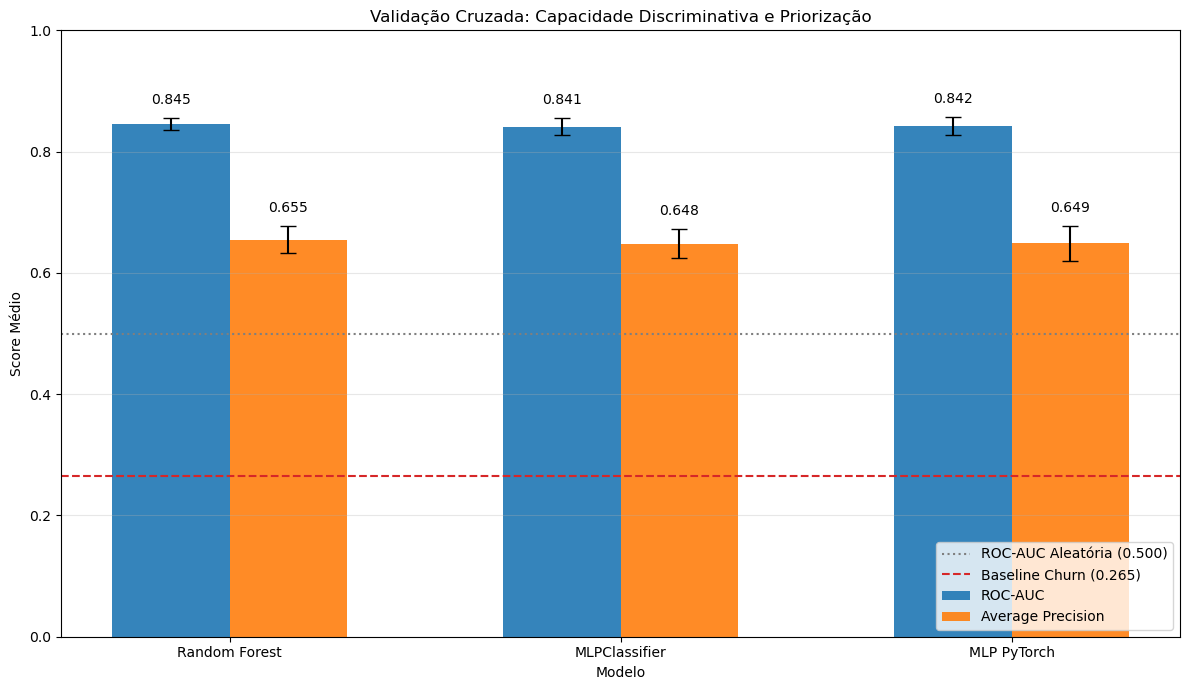

In [19]:
# ============================================================
# ETAPA 9.4.2 - ROC-AUC E AVERAGE PRECISION
# ============================================================
# Comparação das médias e dos desvios-padrão das métricas
# independentes do threshold padrão.
# ============================================================

metricas_probabilidade_cv = [
    "ROC-AUC",
    "Average Precision",
]

modelos_cv = cv_summary[
    "Modelo"
].tolist()

x = np.arange(
    len(modelos_cv)
)

largura = 0.30

cores_probabilidade = [
    "#1f77b4",
    "#ff7f0e",
]


fig, ax = plt.subplots(
    figsize=(12, 7)
)


for indice, (metrica, cor) in enumerate(
    zip(
        metricas_probabilidade_cv,
        cores_probabilidade,
    )
):
    medias = cv_summary[
        f"{metrica} Média"
    ].to_numpy()

    desvios = cv_summary[
        f"{metrica} Desvio"
    ].to_numpy()

    posicoes = (
        x
        + (
            indice
            - (
                len(metricas_probabilidade_cv) - 1
            ) / 2
        )
        * largura
    )

    barras = ax.bar(
        posicoes,
        medias,
        largura,
        yerr=desvios,
        capsize=6,
        label=metrica,
        color=cor,
        alpha=0.90,
    )

    ax.bar_label(
        barras,
        labels=[
            f"{valor:.3f}"
            for valor in medias
        ],
        padding=8,
        fontsize=10,
    )


# Referência de um classificador sem capacidade discriminativa
ax.axhline(
    y=0.50,
    color="#7f7f7f",
    linestyle=":",
    linewidth=1.5,
    label="ROC-AUC Aleatória (0.500)",
)


# Baseline da Average Precision
baseline_churn = y_test.mean()

ax.axhline(
    y=baseline_churn,
    color="#d62728",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Baseline Churn "
        f"({baseline_churn:.3f})"
    ),
)


ax.set_title(
    "Validação Cruzada: Capacidade Discriminativa e Priorização"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "Score Médio"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    modelos_cv
)

ax.set_ylim(
    0,
    1
)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

plt.show()

#### Análise Visual da Capacidade Discriminativa e de Priorização

Os três modelos apresentaram ROC-AUC média próxima de 0,84, permanecendo consideravelmente acima da referência de 0,50 associada a um classificador sem capacidade discriminativa.

O Random Forest alcançou a maior ROC-AUC média, com `0,8449 ± 0,0097`. Além do maior valor médio, apresentou o menor desvio-padrão nessa métrica, indicando maior estabilidade na capacidade de distinguir clientes com e sem churn.

A MLP PyTorch apresentou ROC-AUC média de `0,8419 ± 0,0150`, enquanto o MLPClassifier obteve `0,8411 ± 0,0136`. Embora as diferenças sejam pequenas, os resultados colocam o Random Forest ligeiramente à frente.

Na Average Precision, todos os modelos apresentaram resultados muito superiores à baseline de churn de aproximadamente 26,54%.

O Random Forest obteve a maior Average Precision média, com `0,6550 ± 0,0219`. A MLP PyTorch alcançou `0,6488 ± 0,0288`, enquanto o MLPClassifier apresentou `0,6484 ± 0,0240`.

Além da maior média de Average Precision, o Random Forest apresentou o menor desvio-padrão nessa métrica. Portanto, demonstrou maior estabilidade na priorização dos clientes pertencentes à classe positiva.

Apesar da proximidade entre os resultados, o gráfico confirma a vantagem do Random Forest nas duas métricas independentes do threshold padrão.

### Conclusão da ETAPA 9.4

A análise visual da validação cruzada confirmou os diferentes perfis apresentados pelos modelos.

A MLP PyTorch obteve as maiores médias de Accuracy e Precision, demonstrando maior desempenho geral e maior confiabilidade entre as classificações positivas.

O Random Forest apresentou as maiores médias de Recall e F1-Score, evidenciando maior capacidade de identificar clientes que efetivamente realizaram churn. Também alcançou os melhores resultados de ROC-AUC e Average Precision.

Embora as diferenças de ROC-AUC e Average Precision sejam pequenas, o Random Forest apresentou desvios-padrão inferiores nessas duas métricas, indicando maior estabilidade entre os folds.

Considerando conjuntamente o desempenho médio, a estabilidade, o desbalanceamento das classes e o maior impacto dos Falsos Negativos para o negócio, os resultados da validação cruzada favorecem o Random Forest.

A MLP PyTorch permaneceu competitiva e apresentou a melhor Accuracy e Precision, mas identificou uma proporção menor dos clientes que efetivamente realizaram churn quando utilizado o threshold padrão de 0,50.

---

## ETAPA 10 — Comparação entre Teste e Validação Cruzada

O conjunto de teste fornece uma avaliação final sobre observações que não foram utilizadas durante o treinamento. Entretanto, seu resultado representa apenas uma divisão específica da base.

A validação cruzada complementa essa análise ao avaliar o modelo em diferentes subconjuntos dos dados.

Nesta etapa, os resultados do conjunto de teste serão comparados com as médias da validação cruzada estratificada.

A diferença será calculada da seguinte forma:

`Diferença = Resultado do Teste - Média da Validação Cruzada`

Diferenças próximas de zero indicam que o desempenho observado no teste é coerente com o comportamento médio do modelo.

Diferenças positivas indicam que o resultado no teste foi superior à média da validação cruzada, enquanto diferenças negativas indicam desempenho inferior.

In [20]:
# ============================================================
# ETAPA 10.1 - TESTE VERSUS VALIDAÇÃO CRUZADA
# ============================================================
# Comparação dos resultados do conjunto de teste com as
# médias obtidas na validação cruzada estratificada.
# ============================================================

resultados_teste_cv = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "MLPClassifier",
        "MLP PyTorch",
    ],

    "Accuracy": [
        0.7729,
        0.7850,
        0.7956,
    ],

    "Precision": [
        0.5544,
        0.6330,
        0.6344,
    ],

    "Recall": [
        0.7353,
        0.4519,
        0.5428,
    ],

    "F1-Score": [
        0.6322,
        0.5273,
        0.5850,
    ],

    "ROC-AUC": [
        0.8401,
        0.8341,
        0.8419,
    ],

    "Average Precision": [
        0.6492,
        0.6231,
        0.6349,
    ],
})

comparacao_teste_cv = []

for _, linha_teste in resultados_teste_cv.iterrows():
    modelo = linha_teste["Modelo"]

    linha_cv = cv_summary[
        cv_summary["Modelo"] == modelo
    ].iloc[0]

    for metrica in metricas_cv:
        resultado_teste = linha_teste[metrica]

        media_cv = linha_cv[
            f"{metrica} Média"
        ]

        diferenca = (
            resultado_teste
            - media_cv
        )

        comparacao_teste_cv.append({
            "Modelo": modelo,
            "Métrica": metrica,
            "Teste": resultado_teste,
            "Média CV": media_cv,
            "Diferença": diferenca,
            "Diferença Absoluta": abs(diferenca),
        })


comparacao_teste_cv_df = pd.DataFrame(
    comparacao_teste_cv
)


print(
    "Comparação entre teste e validação cruzada "
    "calculada com sucesso."
)

print(
    f"\nModelos comparados: "
    f"{comparacao_teste_cv_df['Modelo'].nunique()}"
)

print(
    f"Métricas comparadas: "
    f"{comparacao_teste_cv_df['Métrica'].nunique()}"
)

display(
    comparacao_teste_cv_df.style
    .format({
        "Teste": "{:.4f}",
        "Média CV": "{:.4f}",
        "Diferença": "{:+.4f}",
        "Diferença Absoluta": "{:.4f}",
    })
    .set_properties(
        subset=[
            "Teste",
            "Média CV",
            "Diferença",
            "Diferença Absoluta",
        ],
        **{
            "text-align": "center",
        }
    )
    .set_properties(
        subset=[
            "Modelo",
            "Métrica",
        ],
        **{
            "text-align": "left",
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
            ],
        }
    ])
)

Comparação entre teste e validação cruzada calculada com sucesso.

Modelos comparados: 3
Métricas comparadas: 6


,Modelo,Métrica,Teste,Média CV,Diferença,Diferença Absoluta
0,Random Forest,Accuracy,0.7729,0.7748,-0.0019,0.0019
1,Random Forest,Precision,0.5544,0.5584,-0.0040,0.0040
2,Random Forest,Recall,0.7353,0.7224,+0.0129,0.0129
3,Random Forest,F1-Score,0.6322,0.6297,+0.0025,0.0025
4,Random Forest,ROC-AUC,0.8401,0.8449,-0.0048,0.0048
5,Random Forest,Average Precision,0.6492,0.6550,-0.0058,0.0058
6,MLPClassifier,Accuracy,0.7850,0.7954,-0.0104,0.0104
7,MLPClassifier,Precision,0.6330,0.6294,+0.0036,0.0036
8,MLPClassifier,Recall,0.4519,0.5660,-0.1141,0.1141
9,MLPClassifier,F1-Score,0.5273,0.5939,-0.0666,0.0666


#### Análise da Comparação entre Teste e Validação Cruzada

A comparação demonstra que o Random Forest apresentou resultados bastante próximos entre o conjunto de teste e a validação cruzada.

A Accuracy do Random Forest apresentou diferença de apenas `-0,0019`, enquanto a Precision variou `-0,0040`. O Recall obtido no teste foi `0,0129` superior à média da validação cruzada, e o F1-Score apresentou diferença positiva de somente `0,0025`.

Nas métricas independentes do threshold, o Random Forest também manteve comportamento consistente. A diferença foi de `-0,0048` na ROC-AUC e de `-0,0058` na Average Precision.

O MLPClassifier apresentou maior divergência entre as duas avaliações. Seu Recall no conjunto de teste foi `0,1141` inferior à média da validação cruzada, representando uma redução de 11,41 pontos percentuais. O F1-Score também apresentou queda relevante de `0,0666`.

Essas diferenças indicam que o MLPClassifier apresentou menor estabilidade na identificação da classe positiva. Esse comportamento também é coerente com o maior desvio-padrão de Recall observado durante a validação cruzada.

A MLP PyTorch apresentou resultados relativamente próximos entre o teste e a validação cruzada. A diferença foi de `-0,0056` na Accuracy, `-0,0193` na Precision e `+0,0088` no Recall.

O F1-Score da MLP PyTorch apresentou diferença de apenas `-0,0028`, enquanto sua ROC-AUC foi exatamente igual à média da validação cruzada quando considerada a precisão de quatro casas decimais. A Average Precision do teste ficou `0,0139` abaixo da média dos folds.

Portanto, o Random Forest e a MLP PyTorch apresentaram maior coerência entre o desempenho do conjunto de teste e os resultados médios da validação cruzada. O MLPClassifier demonstrou maior sensibilidade à divisão dos dados, principalmente nas métricas Recall e F1-Score.

---

### ETAPA 10.2 — Resumo da Consistência dos Modelos

Para resumir a consistência de cada modelo, será calculada a diferença absoluta média entre os resultados do conjunto de teste e as médias da validação cruzada.

Também será identificada a maior diferença absoluta observada e a métrica responsável por essa diferença.

Essa análise não mede diretamente qual modelo apresenta o melhor desempenho preditivo. Seu objetivo é verificar o quanto o resultado obtido no conjunto de teste representa o comportamento médio observado durante a validação cruzada.

Quanto menor a diferença absoluta média, maior a consistência do modelo entre as duas avaliações.

In [21]:
# ============================================================
# ETAPA 10.2 - RESUMO DA CONSISTÊNCIA DOS MODELOS
# ============================================================
# Cálculo da diferença absoluta média e identificação da
# métrica com maior diferença para cada modelo.
# ============================================================

consistencia_modelos = (
    comparacao_teste_cv_df
    .groupby(
        "Modelo",
        as_index=False,
    )
    .agg(
        Diferenca_Absoluta_Media=(
            "Diferença Absoluta",
            "mean",
        ),
        Maior_Diferenca_Absoluta=(
            "Diferença Absoluta",
            "max",
        ),
    )
)

# Localização da maior diferença absoluta de cada modelo
indices_maiores_diferencas = (
    comparacao_teste_cv_df
    .groupby("Modelo")[
        "Diferença Absoluta"
    ]
    .idxmax()
)

metricas_maior_diferenca = (
    comparacao_teste_cv_df
    .loc[
        indices_maiores_diferencas,
        [
            "Modelo",
            "Métrica",
            "Diferença",
        ],
    ]
    .rename(
        columns={
            "Métrica": "Métrica com Maior Diferença",
            "Diferença": "Diferença da Métrica",
        }
    )
)

# União dos resultados
consistencia_modelos = (
    consistencia_modelos
    .merge(
        metricas_maior_diferenca,
        on="Modelo",
        how="left",
    )
    .sort_values(
        by="Diferenca_Absoluta_Media",
        ascending=True,
    )
    .reset_index(
        drop=True,
    )
)

print(
    "Resumo da consistência calculado com sucesso."
)

print(
    "\nQuanto menor a diferença absoluta média, "
    "maior a consistência."
)

display(
    consistencia_modelos.style
    .format({
        "Diferenca_Absoluta_Media": "{:.4f}",
        "Maior_Diferenca_Absoluta": "{:.4f}",
        "Diferença da Métrica": "{:+.4f}",
    })
    .highlight_min(
        subset=[
            "Diferenca_Absoluta_Media",
        ],
        color="#90EE90",
    )
    .highlight_max(
        subset=[
            "Diferenca_Absoluta_Media",
        ],
        color="#FFB6C1",
    )
    .set_properties(
        subset=[
            "Diferenca_Absoluta_Media",
            "Maior_Diferenca_Absoluta",
            "Diferença da Métrica",
        ],
        **{
            "text-align": "center",
        }
    )
    .set_properties(
        subset=[
            "Modelo",
            "Métrica com Maior Diferença",
        ],
        **{
            "text-align": "left",
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
            ],
        }
    ])
)

Resumo da consistência calculado com sucesso.

Quanto menor a diferença absoluta média, maior a consistência.


,Modelo,Diferenca_Absoluta_Media,Maior_Diferenca_Absoluta,Métrica com Maior Diferença,Diferença da Métrica
0,Random Forest,0.0053,0.0129,Recall,+0.0129
1,MLP PyTorch,0.0084,0.0193,Precision,-0.0193
2,MLPClassifier,0.0378,0.1141,Recall,-0.1141


#### Análise da Consistência dos Modelos

O Random Forest apresentou a menor diferença absoluta média entre o conjunto de teste e a validação cruzada, com valor de `0,0053`. Isso significa que, considerando as seis métricas avaliadas, seus resultados diferiram em média apenas 0,53 ponto percentual entre as duas avaliações.

A maior diferença do Random Forest ocorreu no Recall. O resultado do conjunto de teste foi `0,0129` superior à média da validação cruzada. Mesmo sendo sua maior variação, a diferença permaneceu pequena, indicando consistência na identificação dos clientes que efetivamente realizaram churn.

A MLP PyTorch apresentou a segunda menor diferença absoluta média, com `0,0084`. Sua maior divergência ocorreu na Precision, que ficou `0,0193` abaixo da média obtida na validação cruzada. Ainda assim, o modelo apresentou boa consistência geral.

O MLPClassifier apresentou a maior diferença absoluta média, com `0,0378`. Sua maior divergência ocorreu no Recall, cujo resultado no teste ficou `0,1141` abaixo da média da validação cruzada.

A queda de 11,41 pontos percentuais no Recall indica que o MLPClassifier foi mais sensível à divisão específica dos dados. Portanto, seu resultado no conjunto de teste representou com menor fidelidade o comportamento médio observado nos folds.

### Conclusão da ETAPA 10

A comparação entre os resultados do conjunto de teste e as médias da validação cruzada permitiu avaliar a consistência e a capacidade de generalização dos modelos.

O Random Forest apresentou a maior consistência, com diferença absoluta média de apenas `0,0053`. Seus resultados de Accuracy, Precision, Recall, F1-Score, ROC-AUC e Average Precision permaneceram próximos das respectivas médias obtidas nos cinco folds.

A MLP PyTorch também apresentou comportamento consistente, com diferença absoluta média de `0,0084`. Esse resultado indica que o desempenho observado no conjunto de teste foi compatível com sua capacidade média de generalização.

O MLPClassifier apresentou menor consistência, com diferença absoluta média de `0,0378`. A principal divergência ocorreu no Recall, que apresentou uma queda expressiva no conjunto de teste em comparação à validação cruzada.

Portanto, a análise de consistência reforça a escolha do Random Forest. Além de apresentar os melhores resultados médios de Recall, F1-Score, ROC-AUC e Average Precision, o modelo também demonstrou a menor divergência entre o conjunto de teste e a validação cruzada.

A MLP PyTorch permaneceu como uma alternativa competitiva e estável, especialmente nas métricas Accuracy e Precision. Entretanto, no threshold padrão de 0,50, apresentou menor capacidade de identificar clientes que efetivamente realizaram churn.

---

## ETAPA 11 — Seleção e Justificativa do Modelo Final

A escolha do modelo final deve considerar conjuntamente o desempenho estatístico, a estabilidade, os tipos de erro e o impacto estimado para o negócio.

Neste projeto, a seleção não será baseada exclusivamente na Accuracy. Como a base possui classes desbalanceadas e a não identificação de um cliente que realizará churn pode representar uma oportunidade de retenção perdida, as métricas Recall, F1-Score e Average Precision possuem maior relevância.

Também serão considerados:

- resultados no conjunto de teste;
- médias da validação cruzada estratificada;
- estabilidade entre teste e validação cruzada;
- quantidade de Falsos Negativos;
- custo relativo dos erros;
- capacidade de generalização;
- objetivo acadêmico de desenvolvimento de uma MLP com PyTorch.

In [23]:
# ============================================================
# ETAPA 11.1 - CONSOLIDAÇÃO DOS CRITÉRIOS DE SELEÇÃO
# ============================================================
# Resumo dos principais resultados utilizados para justificar
# a recomendação do modelo final.
# ============================================================

selecao_modelo_final = pd.DataFrame({
    "Critério": [
        "Maior Accuracy no teste",
        "Maior Precision no teste",
        "Maior Recall no teste",
        "Maior F1-Score no teste",
        "Maior ROC-AUC no teste",
        "Maior Average Precision no teste",
        "Maior Accuracy média na CV",
        "Maior Precision média na CV",
        "Maior Recall médio na CV",
        "Maior F1-Score médio na CV",
        "Maior ROC-AUC média na CV",
        "Maior Average Precision média na CV",
        "Menor quantidade de Falsos Negativos",
        "Menor custo relativo total",
        "Maior consistência teste versus CV",
    ],

    "Modelo Vencedor": [
        "Regressão Logística",
        "Regressão Logística",
        "Random Forest",
        "Random Forest",
        "Regressão Logística / MLP PyTorch",
        "Random Forest",
        "MLP PyTorch",
        "MLP PyTorch",
        "Random Forest",
        "Random Forest",
        "Random Forest",
        "Random Forest",
        "Random Forest",
        "Random Forest",
        "Random Forest",
    ],

    "Resultado": [
        "0.8055",
        "0.6572",
        "0.7353",
        "0.6322",
        "0.8419",
        "0.6492",
        "0.8012 ± 0.0112",
        "0.6537 ± 0.0271",
        "0.7224 ± 0.0341",
        "0.6297 ± 0.0208",
        "0.8449 ± 0.0097",
        "0.6550 ± 0.0219",
        "99",
        "716",
        "Diferença média de 0.0053",
    ],
})

print(
    "Critérios de seleção consolidados com sucesso."
)

print(
    f"\nQuantidade de critérios avaliados: "
    f"{len(selecao_modelo_final)}"
)

display(
    selecao_modelo_final.style
    .set_properties(
        subset=[
            "Critério",
            "Modelo Vencedor",
            "Resultado",
        ],
        **{
            "text-align": "left",
        }
    )
    .apply(
        lambda coluna: [
            (
                "background-color: #90EE90; "
                "color: #000000; "
                "font-weight: bold"
                if valor == "Random Forest"
                else ""
            )
            for valor in coluna
        ],
        subset=[
            "Modelo Vencedor",
        ],
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
            ],
        }
    ])
)

Critérios de seleção consolidados com sucesso.

Quantidade de critérios avaliados: 15


,Critério,Modelo Vencedor,Resultado
0,Maior Accuracy no teste,Regressão Logística,0.8055
1,Maior Precision no teste,Regressão Logística,0.6572
2,Maior Recall no teste,Random Forest,0.7353
3,Maior F1-Score no teste,Random Forest,0.6322
4,Maior ROC-AUC no teste,Regressão Logística / MLP PyTorch,0.8419
5,Maior Average Precision no teste,Random Forest,0.6492
6,Maior Accuracy média na CV,MLP PyTorch,0.8012 ± 0.0112
7,Maior Precision média na CV,MLP PyTorch,0.6537 ± 0.0271
8,Maior Recall médio na CV,Random Forest,0.7224 ± 0.0341
9,Maior F1-Score médio na CV,Random Forest,0.6297 ± 0.0208


#### Análise dos Critérios de Seleção

Foram considerados 15 critérios relacionados ao desempenho no conjunto de teste, à validação cruzada, aos erros de classificação, ao custo relativo e à consistência dos modelos.

O Random Forest apresentou o melhor resultado em 10 dos 15 critérios avaliados. O modelo alcançou o maior Recall, F1-Score e Average Precision no conjunto de teste.

Na validação cruzada, o Random Forest também obteve as maiores médias de Recall, F1-Score, ROC-AUC e Average Precision.

Além das métricas preditivas, o modelo apresentou a menor quantidade de Falsos Negativos, com 99 clientes que efetivamente realizaram churn e não foram identificados.

Na simulação em que um Falso Negativo possui custo cinco vezes maior que um Falso Positivo, o Random Forest registrou o menor custo relativo total, com 716 unidades.

O modelo também apresentou a maior consistência entre o conjunto de teste e a validação cruzada, com diferença absoluta média de apenas 0,0053.

A Regressão Logística apresentou a maior Accuracy e Precision no conjunto de teste. Também empatou com a MLP PyTorch na maior ROC-AUC, considerando quatro casas decimais.

A MLP PyTorch apresentou as maiores médias de Accuracy e Precision durante a validação cruzada, demonstrando bom desempenho geral e maior confiabilidade entre as classificações positivas.

Entretanto, considerando a identificação da classe positiva, o custo dos erros e a estabilidade dos resultados, o Random Forest apresentou o conjunto mais favorável de evidências.

---

### ETAPA 11.2 — Escolha do Modelo Final

Com base nos resultados obtidos, o **Random Forest é recomendado como modelo final para o cenário de negócio analisado**.

A recomendação é sustentada pelos seguintes resultados:

- Recall de 73,53% no conjunto de teste;
- F1-Score de 63,22% no conjunto de teste;
- ROC-AUC de 84,01% no conjunto de teste;
- Average Precision de 64,92% no conjunto de teste;
- Recall médio de `72,24% ± 3,41%` na validação cruzada;
- F1-Score médio de `62,97% ± 2,08%`;
- ROC-AUC média de `84,49% ± 0,97%`;
- Average Precision média de `65,50% ± 2,19%`;
- menor quantidade de Falsos Negativos, com 99 ocorrências;
- menor custo relativo total, com 716 unidades;
- menor diferença absoluta média entre teste e validação cruzada, com 0,0053.

O Random Forest apresentou a melhor capacidade de identificar clientes que efetivamente realizaram churn e manteve desempenho estável em diferentes divisões dos dados.

Sua principal limitação foi a maior quantidade de Falsos Positivos, com 221 ocorrências. Isso significa que mais clientes que permaneceriam naturalmente poderiam ser encaminhados desnecessariamente para ações de retenção.

Entretanto, na hipótese de negócio adotada, em que o custo de um Falso Negativo é cinco vezes maior que o custo de um Falso Positivo, a redução dos clientes de churn não identificados compensou o aumento dos alertas incorretos.

A **MLP PyTorch permanece como o principal modelo de rede neural desenvolvido no projeto**, atendendo ao objetivo acadêmico de implementação, treinamento e avaliação de uma arquitetura MLP utilizando um framework de Deep Learning.

A rede neural apresentou resultados competitivos, com Accuracy de 79,56%, ROC-AUC de 84,19% e Average Precision de 63,49% no conjunto de teste. Também apresentou boa consistência entre o teste e a validação cruzada, com diferença absoluta média de 0,0084.

Dessa forma, o projeto apresenta duas conclusões complementares:

1. o Random Forest é o modelo recomendado para uma aplicação voltada ao cenário de negócio analisado;
2. a MLP PyTorch é a principal solução de rede neural desenvolvida e validada durante o projeto.

A recomendação considera o threshold padrão de 0,50 e uma simulação de custo relativo, e não valores financeiros reais. Antes de uma implantação em produção, os custos dos erros e o threshold de classificação deverão ser validados com as áreas responsáveis pelo negócio.

---

### ETAPA 12 — Conclusão Geral da Comparação dos Modelos

Este notebook realizou uma comparação padronizada entre diferentes algoritmos de classificação aplicados à previsão de churn de clientes.

Foram considerados os seguintes modelos:

- DummyClassifier;
- Regressão Logística;
- Random Forest;
- MLPClassifier do Scikit-learn;
- MLP desenvolvida com PyTorch.

O DummyClassifier foi utilizado como baseline e demonstrou a importância de não avaliar um problema com classes desbalanceadas utilizando apenas a Accuracy. Embora tenha alcançado Accuracy de 73,46%, o modelo não identificou nenhum cliente com churn, resultando em Recall e F1-Score iguais a zero.

Todos os modelos treinados apresentaram resultados significativamente superiores ao baseline, demonstrando que as variáveis disponíveis possuem capacidade relevante para explicar e prever o comportamento de churn.

### ETAPA 12.1 — Síntese dos Resultados

A Regressão Logística apresentou a maior Accuracy no conjunto de teste, com 80,55%, e a maior Precision, com 65,72%. O modelo demonstrou bom desempenho geral e boa capacidade discriminativa, alcançando ROC-AUC de 84,19%.

O Random Forest apresentou o maior Recall, com 73,53%, o maior F1-Score, com 63,22%, e a maior Average Precision, com 64,92%. Também registrou somente 99 Falsos Negativos, sendo o modelo que identificou a maior parcela dos clientes que efetivamente realizaram churn.

O MLPClassifier apresentou Accuracy de 78,50%, Precision de 63,30%, Recall de 45,19%, F1-Score de 52,73%, ROC-AUC de 83,41% e Average Precision de 62,31%. Apesar de apresentar boa Precision, o modelo demonstrou menor capacidade de identificar a classe positiva no conjunto de teste.

A MLP PyTorch apresentou Accuracy de 79,56%, Precision de 63,44%, Recall de 54,28%, F1-Score de 58,50%, ROC-AUC de 84,19% e Average Precision de 63,49%. A rede neural apresentou desempenho competitivo e boa estabilidade entre o teste e a validação cruzada.

Na validação cruzada estratificada, o Random Forest manteve as melhores médias de Recall, F1-Score, ROC-AUC e Average Precision. A MLP PyTorch apresentou as maiores médias de Accuracy e Precision.

A comparação entre teste e validação cruzada demonstrou que o Random Forest foi o modelo mais consistente, com diferença absoluta média de 0,0053. A MLP PyTorch apresentou a segunda maior consistência, com diferença de 0,0084, enquanto o MLPClassifier apresentou diferença de 0,0378.

### ETAPA 12.2 — Perspectiva de Negócio

No contexto de churn, os diferentes tipos de erro produzem impactos distintos.

Um Falso Positivo representa um cliente classificado como possível churn, mas que permaneceria na empresa. Esse erro pode gerar gastos desnecessários com campanhas, descontos ou ações de retenção.

Um Falso Negativo representa um cliente que efetivamente realizará churn, mas que não foi identificado pelo modelo. Esse cenário pode impedir que a empresa realize uma ação preventiva antes da saída do cliente.

Na simulação em que um Falso Negativo possui custo cinco vezes maior que um Falso Positivo, foram obtidos os seguintes custos relativos:

- DummyClassifier: 1.870 unidades;
- Regressão Logística: 934 unidades;
- Random Forest: 716 unidades;
- MLPClassifier: 1.123 unidades;
- MLP PyTorch: 972 unidades.

O Random Forest apresentou o menor custo relativo total, representando uma redução de aproximadamente 61,71% em relação ao DummyClassifier.

Esse resultado ocorreu porque o modelo reduziu significativamente os Falsos Negativos, mesmo produzindo uma quantidade maior de Falsos Positivos.

Portanto, quando o custo de perder um cliente é superior ao custo de realizar uma abordagem preventiva desnecessária, o Random Forest apresenta o comportamento mais favorável para o negócio.

### ETAPA 12.3 — Modelo Recomendado

Com base no conjunto de evidências, o **Random Forest é recomendado como modelo final para o cenário de negócio avaliado**.

A escolha considera:

- maior Recall no conjunto de teste;
- maior F1-Score no conjunto de teste;
- maior Average Precision no conjunto de teste;
- melhores médias de Recall, F1-Score, ROC-AUC e Average Precision na validação cruzada;
- menor quantidade de Falsos Negativos;
- menor custo relativo total;
- maior consistência entre teste e validação cruzada.

Entretanto, a escolha não significa que o modelo seja superior em todos os aspectos. A Regressão Logística apresentou maior Accuracy e Precision no teste, enquanto a MLP PyTorch apresentou as maiores médias dessas duas métricas durante a validação cruzada.

A MLP PyTorch permanece como a principal solução de rede neural desenvolvida neste projeto. Sua implementação permitiu demonstrar:

- construção manual de uma arquitetura MLP;
- utilização de camadas densas, ReLU e Dropout;
- treinamento com BCEWithLogitsLoss e Adam;
- aplicação de regularização L2;
- utilização de Early Stopping;
- restauração dos melhores pesos;
- geração de probabilidades;
- avaliação de diferentes thresholds;
- análise de custos dos erros;
- validação cruzada estratificada.

Dessa maneira, o Random Forest é recomendado para o cenário operacional analisado, enquanto a MLP PyTorch representa a principal entrega técnica relacionada ao desenvolvimento de redes neurais.

### ETAPA 12.4 — Limitações do Estudo

Os resultados devem ser interpretados considerando algumas limitações.

A base utilizada possui 7.043 observações e representa um recorte específico do setor de telecomunicações. Portanto, o desempenho observado não garante que os modelos apresentarão os mesmos resultados em outras empresas, períodos ou populações.

A simulação de custos utilizou uma proporção hipotética de 1 para 5 entre Falsos Positivos e Falsos Negativos. Esses valores não representam custos financeiros reais e deverão ser substituídos por estimativas fornecidas pelas áreas de negócio.

A comparação principal utilizou o threshold padrão de 0,50. A alteração desse threshold modifica diretamente Precision, Recall, Falsos Positivos, Falsos Negativos e o custo das decisões.

A Regressão Logística participou integralmente da avaliação no conjunto de teste, mas não foi incluída na comparação de estabilidade por validação cruzada neste notebook.

Também não foram realizados testes estatísticos formais para determinar se as pequenas diferenças de ROC-AUC e Average Precision entre os modelos são estatisticamente significativas.

Por fim, os modelos foram avaliados utilizando dados históricos. Alterações no comportamento dos clientes ao longo do tempo podem provocar degradação de desempenho, fenômeno conhecido como data drift.

In [24]:
# ============================================================
# ETAPA 12.6 - ENCERRAMENTO DO NOTEBOOK
# ============================================================

modelo_recomendado = "Random Forest"

modelo_rede_neural = "MLP PyTorch"

criterio_principal = "Average Precision"

threshold_comparacao = 0.50


print(
    "Comparação dos modelos concluída com sucesso."
)

print(
    f"\nModelo recomendado para o negócio: "
    f"{modelo_recomendado}"
)

print(
    f"Principal modelo de rede neural: "
    f"{modelo_rede_neural}"
)

print(
    f"Principal métrica técnica: "
    f"{criterio_principal}"
)

print(
    f"Threshold utilizado na comparação: "
    f"{threshold_comparacao:.2f}"
)

print(
    "\nPróxima etapa: rastreamento dos experimentos "
    "e gerenciamento do ciclo de vida dos modelos."
)

Comparação dos modelos concluída com sucesso.

Modelo recomendado para o negócio: Random Forest
Principal modelo de rede neural: MLP PyTorch
Principal métrica técnica: Average Precision
Threshold utilizado na comparação: 0.50

Próxima etapa: rastreamento dos experimentos e gerenciamento do ciclo de vida dos modelos.
